# 0. Setup & data loader

The loader below is the same one used in the three companion notebooks. It downloads the public mirror of the Viador booking dataset and adds two helper columns (`booking_date`, `adr_per_adult`).

In [3]:
import numpy as np
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/mpolinowski/hotel-booking-dataset"
    "/refs/heads/master/datasets/hotel_bookings.csv"
)


def load_bookings():
    df = pd.read_csv(DATA_URL)
    df["arrival_date"] = pd.to_datetime(
        df["arrival_date_year"].astype(str)
        + "-"
        + df["arrival_date_month"]
        + "-"
        + df["arrival_date_day_of_month"].astype(str),
        format="%Y-%B-%d",
        errors="coerce",
    )
    df["booking_date"] = df["arrival_date"] - pd.to_timedelta(
        df["lead_time"], unit="D"
    )
    df["adr_per_adult"] = df["adr"] / df["adults"].clip(lower=1)
    return df


bookings = load_bookings()
bookings.shape, bookings["arrival_date"].min(), bookings["arrival_date"].max()

((119390, 35),
 Timestamp('2015-07-01 00:00:00'),
 Timestamp('2017-08-31 00:00:00'))

In [4]:
#shared imports
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## §Q1 · Calibrate Advance Sale Policies

Clara offers discounted advance rates but only up to a certain number of bookings. Selling too many in advance turns away spontaneous, higher-paying guests; selling too few leaves occupancy short.

- Using **realised stays**, identify meaningful guest segments for each hotel. *When* do different guest types book? *What* prices do they pay?
- Estimate how many rooms Clara could allocate to advance sales **for each property**. Focus on lead times and, if useful, guest mix.

### Prevention of Data Distortion: Realized Stays Only

Analysing the commercial mix of both hotels requires focusing on realised bookings only. Including cancellations would overestimate true segment demand and distort price comparisons, since cancelled rates were never actually paid.

In [5]:
#realised bookings only df

realised = bookings[bookings["is_canceled"] == 0]
realised.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,booking_date,adr_per_adult
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,01-07-15,2015-07-01,2014-07-24,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,01-07-15,2015-07-01,2013-06-24,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,02-07-15,2015-07-01,2015-06-24,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,02-07-15,2015-07-01,2015-06-18,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,03-07-15,2015-07-01,2015-06-17,49.0


#### Lead Time Effects on Cancellation Rates

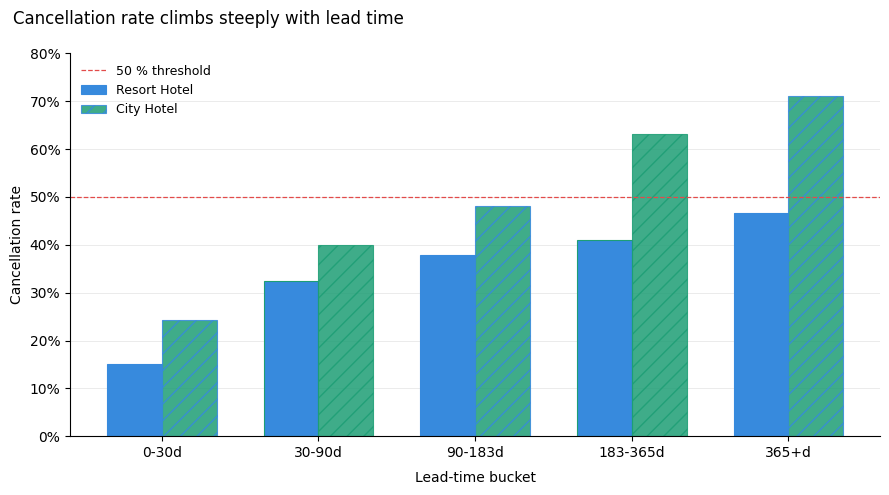

In [6]:
bookings["lead_bucket"] = (
    pd.cut(bookings["lead_time"],    #pd.cut() teilt kontinuierliche daten in bins ein
    [0, 30, 90, 183, 365, np.inf])  #list an buckets
)
canc_book = bookings.groupby(["hotel", "lead_bucket"], observed=True)["is_canceled"].mean() #pro bucket für jedes hotel durchschnitt an cancellations (=anteil, weil binär)

#bar plot
hotels = ["Resort Hotel", "City Hotel"]
buckets_canc = canc_book.index.get_level_values("lead_bucket").unique()
buckets_canc_labels = ["0-30d", "30-90d", "90-183d", "183-365d", "365+d"]

#layout
fig, ax = plt.subplots(figsize=(9, 5))
n_hotels = len(hotels)
x_ax = np.arange(len(buckets_canc)) #array mit fortlaufenden indizes für anzahl buckets
width_canc = 0.35
colors = ["#378ADD", "#1D9E75"]
hatches = [None, "//"]  

for i, ((hotel, color, hatch)) in enumerate(zip(hotels, colors, hatches)):      #zip(): macht tupel aus 1.:1. objekt, 2.:2. objekt usw.; enumerate(): gibt fortlaufende nummer pro tupel
    rates = [canc_book.loc[(hotel, b)] for b in buckets_canc] #für jeden bucket: schaut im cancelled grouped objekt nach der Kombination an (hotel, bucket) und holt den Anteil
    ax.bar(
        x_ax + (i - (n_hotels - 1)/2) * width_canc, #position der bars berechnen: über grundposition, breite der einzelnen bars und index (welches i-te hotel)
        rates,
        width_canc,
        label = hotel,
        color = color,
        alpha = 0.85 if hatch else 1.0,
        hatch = hatch,
        edgecolor = colors,
        linewidth = 0.8,
    )

ax.axhline(0.5, color="#E24B4A", linewidth=0.9, linestyle="--", label="50 % threshold")

ax.set_xticks(x_ax)
ax.set_xticklabels(buckets_canc_labels)
ax.set_xlabel("Lead-time bucket", labelpad=8)
ax.set_ylabel("Cancellation rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 0.80)
ax.yaxis.grid(True, linewidth=0.4, color="gainsboro")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(frameon=False, fontsize=9)
fig.suptitle(
    "Cancellation rate climbs steeply with lead time",
    x=0.02, ha="left", fontsize=12, fontweight="medium",
)

plt.tight_layout()
plt.show()

Clara's pricing decisions should reflect what guests actually paid, not what they intended to pay. Since cancellation rates vary systematically with lead time, including cancelled bookings would distort both segment volumes and price comparisons. All subsequent analysis is therefore restricted to realised stays.

### Controlling for Composition Effects: Canonical homogenisation

Before analysing guest segments, we need to decide how to define them. We use booking lead time as the segmentation criterion, since early and late bookers tend to represent structurally different guest types with different price sensitivities. However, room type, meal plan, and party size may also influence ADR independently. If their mix differs systematically between early and late bookers, any timing gap we measure would be partly a composition effect rather than a genuine pricing signal.


To assess how much each dimension actually moves ADR, we plot ADR distributions by room type, meal plan, and party size separately for each hotel. If the spread across categories is large, that dimension needs to be held fixed before any early/late comparison is meaningful.

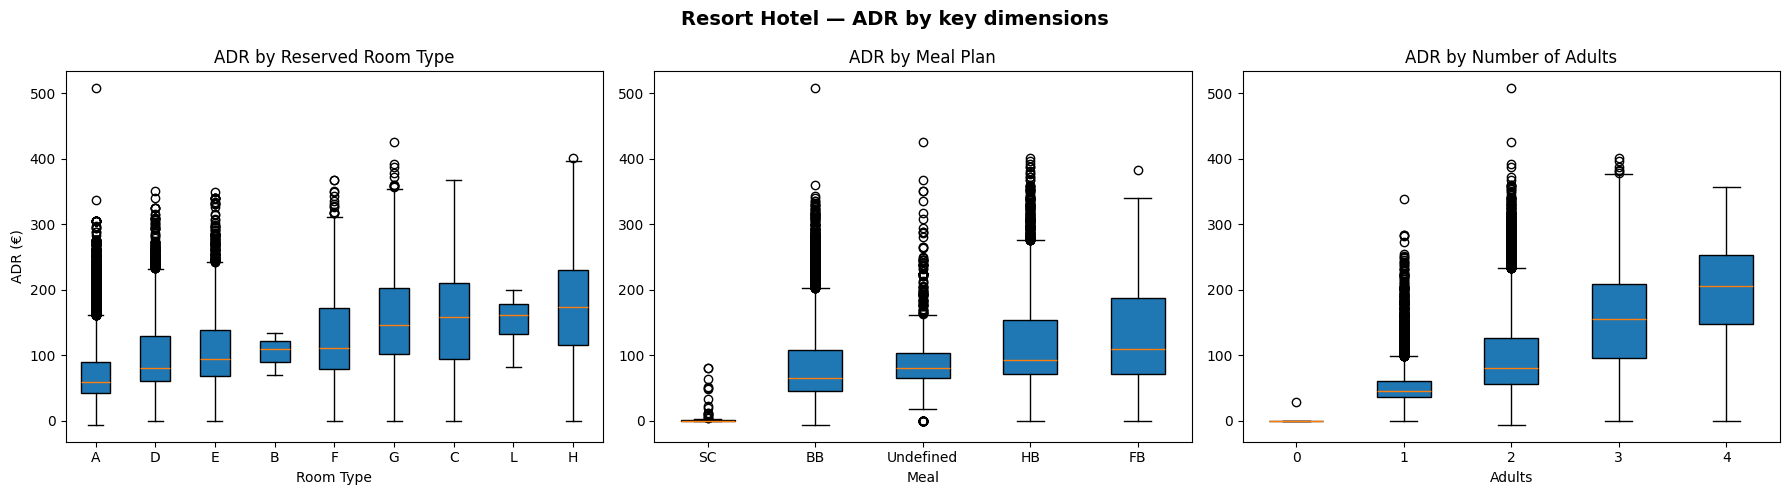

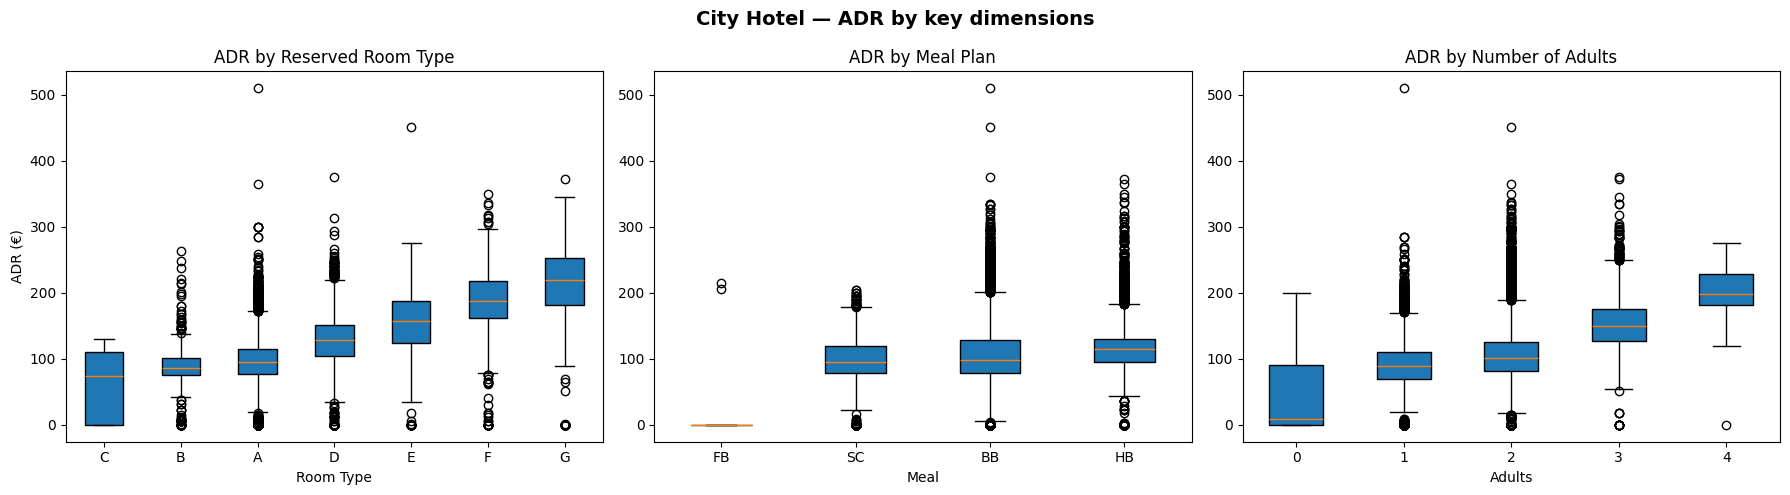

Median ADR by room type (€)


,Resort Hotel,City Hotel
reserved_room_type,,
A,58.98,94.50
B,110.00,86.50
C,158.67,74.00
D,80.00,129.18
E,93.67,157.98
F,111.46,187.85
G,146.61,219.46
H,174.00,NaN
L,161.00,NaN


Median ADR by meal plan (€)


,Resort Hotel,City Hotel
meal,,
BB,65.42,99.0
FB,110.00,0.0
HB,93.00,114.4
SC,0.00,95.1
Undefined,80.00,NaN


Median ADR by number of adults (€)


,Resort Hotel,City Hotel
adults,,
0,0.00,8.34
1,45.00,89.00
2,80.00,101.00
3,155.00,150.30
4,205.33,198.54


Spread per dimension (€)


,Room Type,Meal Plan,Adults
Hotel,,,
Resort Hotel,115.02,110.0,205.33
City Hotel,145.46,114.4,190.20


In [7]:
#plots
median_tables = {"reserved_room_type": {}, "meal": {}, "adults": {}}
spread_rows = []

for hotel in hotels:
    df = realised[realised["hotel"] == hotel] #durch beide hotels loopen

    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{hotel} — ADR by key dimensions", fontsize=14, fontweight="bold")

    #room type
    order_room = df.groupby("reserved_room_type")["adr"].median().sort_values().index   #nach room groupen und medain pro roomtype, nach median ordnen; .index holt nur sortierte room_types
    groups_room = [df[df["reserved_room_type"] == r]["adr"] for r in order_room] #für jeden room type liste aller preise
    axes[0].boxplot(groups_room, tick_labels=order_room, patch_artist=True)
    axes[0].set_title("ADR by Reserved Room Type")
    axes[0].set_xlabel("Room Type")
    axes[0].set_ylabel("ADR (€)")

    #meal code logik identisch
    order_meal = df.groupby("meal")["adr"].median().sort_values().index
    groups_meal = [df[df["meal"] == m]["adr"] for m in order_meal]
    axes[1].boxplot(groups_meal, tick_labels=order_meal, patch_artist=True)
    axes[1].set_title("ADR by Meal Plan")
    axes[1].set_xlabel("Meal")

    #adults
    order_adults = sorted(df["adults"].unique())    #alle möglichkeiten an anzahl, sortiert
    groups_adults = [df[df["adults"] == a]["adr"] for a in order_adults]
    axes[2].boxplot(groups_adults, tick_labels=[str(int(a)) for a in order_adults], patch_artist=True)
    axes[2].set_title("ADR by Number of Adults")
    axes[2].set_xlabel("Adults")

    plt.tight_layout()
    plt.show()

    #quantifizierung sammeln
    for dim in ["reserved_room_type", "meal", "adults"]:
        med = df.groupby(dim)["adr"].median()
        median_tables[dim][hotel] = med

    spread_rows.append({
        "Hotel": hotel,
        "Room Type": median_tables["reserved_room_type"][hotel].max() - median_tables["reserved_room_type"][hotel].min(),
        "Meal Plan": median_tables["meal"][hotel].max() - median_tables["meal"][hotel].min(),
        "Adults": median_tables["adults"][hotel].max() - median_tables["adults"][hotel].min(),
    })

#erst nach dem loop: alle tabellen
print("Median ADR by room type (€)")
display(pd.DataFrame(median_tables["reserved_room_type"]).round(2))

print("Median ADR by meal plan (€)")
display(pd.DataFrame(median_tables["meal"]).round(2))

print("Median ADR by number of adults (€)")
display(pd.DataFrame(median_tables["adults"]).round(2))

print("Spread per dimension (€)")
display(pd.DataFrame(spread_rows).set_index("Hotel").round(2))

The boxplots and spread calculations show that each of the three dimensions individually shifts median ADR by €110 to €205, an amount large enough to manufacture or erase any timing effect entirely. If room type, meal plan, or party size are left free, a difference in booking mix between early and late guests would contaminate the gap we measure, making it impossible to attribute to pricing rather than composition. We therefore fix all three jointly before running any customer segment comparison.

However, fixing a tuple is only meaningful if it reflects how guests actually book. A canonical choice that covers a negligible share of realised stays produces unstable medians and an unrepresentative baseline. We therefore identify the modal (room, meal, adults) combination per hotel by frequency:

The tuple that is both the most common realised booking and carries enough volume to yield reliable estimates on both sides of any lead-time cut.

In [8]:
combo = (
    realised.groupby(["hotel", "reserved_room_type", "meal", "adults"]) #nach tupel gruppieren für jedes hotel
    .size()     #anzahl zählen
    .reset_index(name="n")  
    .sort_values(["hotel", "n"], ascending=[True, False])   #sortieren: zuerst nach hotel, dann der häufigkeit nach
)

hotel_totals = realised.groupby("hotel").size().rename("hotel_total")   #bookings pro hotel
combo = combo.join(hotel_totals, on="hotel")        #zusammenführen
combo["share_pct"] = (combo["n"] / combo["hotel_total"] * 100).round(2) #anteil spalte

print("Top 5 tuples per hotel:\n")
for hotel, grp in combo.groupby("hotel"):       #grp ist df mit nur einträgen des hotels
    top5 = grp.head(5).reset_index(drop=True)   #combo schon sortier, also einfach obersten 5 holen
    cumulative = top5["share_pct"].sum()        #anteile der top 5 summieren für kumulativen anteil
    print(f"Hotel: {hotel}  (total realised bookings: {grp['hotel_total'].iloc[0]:,})")
    print(top5[["reserved_room_type", "meal", "adults", "n", "share_pct"]].to_string(index=False))
    print(f"Top-5 tuples cover {cumulative:.1f}% of this hotel's realised bookings\n")

Top 5 tuples per hotel:

Hotel: City Hotel  (total realised bookings: 46,228)
reserved_room_type meal  adults     n  share_pct
                 A   BB       2 17506      37.87
                 A   BB       1  7436      16.09
                 A   SC       2  5291      11.45
                 D   BB       2  4440       9.60
                 A   HB       2  2578       5.58
Top-5 tuples cover 80.6% of this hotel's realised bookings

Hotel: Resort Hotel  (total realised bookings: 28,938)
reserved_room_type meal  adults    n  share_pct
                 A   BB       2 8600      29.72
                 A   BB       1 4304      14.87
                 D   BB       2 3655      12.63
                 E   BB       2 2380       8.22
                 A   HB       2 2210       7.64
Top-5 tuples cover 73.1% of this hotel's realised bookings



The most representative booking type for both hotels is A/BB/2 by a considerable margin, so we fix it as the shared canonical tuple for all subsequent analysis. Coverage is strongly concentrated. The top five tuples account for 80.6% of City Hotel and 73.1% of Resort Hotel realised bookings, with a steep drop in frequency after the modal entry. A single canonical tuple as the basis for further modelling is therefore well justified.
To confirm that the early/late structure is not an artefact of party size, we later re-run the segment analysis on A/BB/1.

We further restrict the analysis to realised bookings with an ADR between €0 and €250 and a lead time of at most 365 days. A nightly rate above €250 or a booking horizon beyond one year falls outside the plausible operating range of a typical city or resort hotel, so observations outside these bounds are treated as data artefacts that would distort distributional summaries without reflecting genuine pricing behaviour.

Fixing the canonical tuple removes the compositional bias from room type, meal plan, and party size, but a second confounder remains. Seasonality. If early and late bookers systematically arrive in different months, any ADR gap we measure would partly reflect the seasonal price level, not the timing of the booking decision. To isolate a clean lead-time effect, we therefore identify the months where ADR is structurally elevated and restrict the early/late comparison to those months. We first inspect the demand calendar, both arrival volume and canonical ADR, over the full 2015 to 2017 timeline to determine which months constitute the economically relevant high season.

### Identification of Seasonal Peak Demand

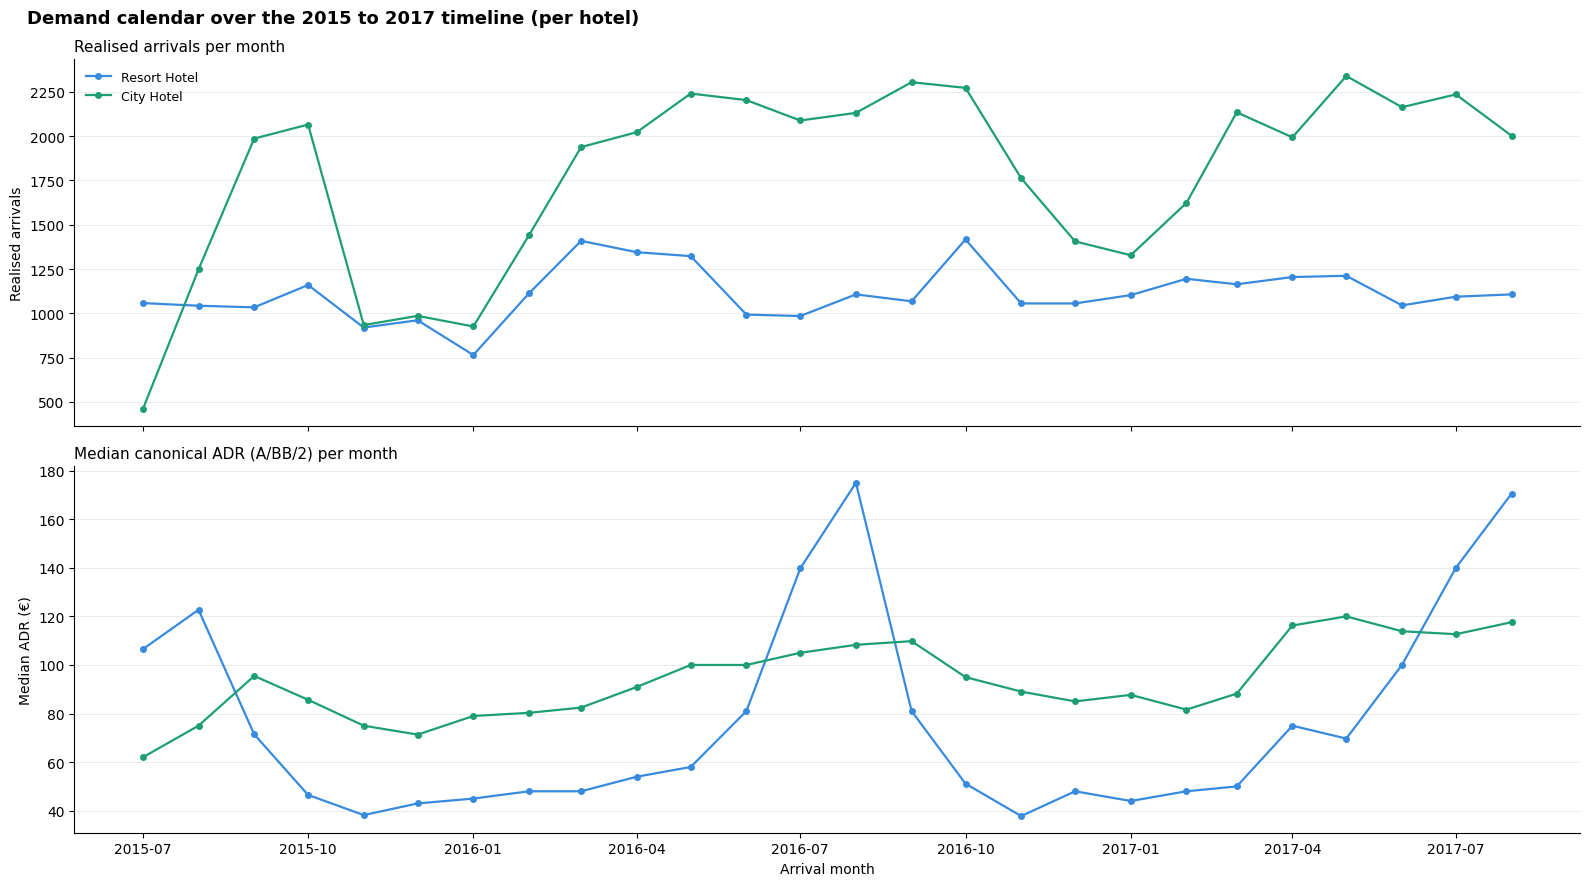

arrival_date_month,April,August,December,February,January,July,June,March,May,November,October,September
hotel,,,,,,,,,,,,
City Hotel,1549,2089,997,1064,717,1609,1553,1649,1720,1036,1804,1719
Resort Hotel,573,922,504,707,601,944,618,703,804,613,969,642


In [9]:
# arrival time series_ realised arrivals per month over entire timeline 

hotel_colors = dict(zip(hotels, colors))    #listen von oben verwenden

#canonical parameters

rooms = "A"
meals = "BB"
adults = 2

realised = realised.copy()
realised["arrival_ym"] = realised["arrival_date"].dt.to_period("M").dt.to_timestamp()   #ym spalte: zur vorbereitung für aggregation

canon = realised[
    (realised["reserved_room_type"] == rooms)
    & (realised["meal"] == meals)
    & (realised["adults"] == adults)
]

arrivals_ts = (
    realised.groupby(["arrival_ym", "hotel"])   #nach monat und hotel groupen
    .size()                                     #arrivals pro monat zählen
    .reset_index(name="value")
)

adr_ts = (
    canon.groupby(["arrival_ym", "hotel"])["adr"]   #selbe logik nur median
    .median()
    .reset_index(name="value")
)


monthly_time_series = (
    realised.groupby(["arrival_ym", "hotel"]) 
    .size()                                     
    .reset_index(name="n_arrivals")
)

#kleine helper function damit wir nicht zwei loops machen müssen:

fig, (ax_arr, ax_adr) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

def draw(ax, data, ylabel):
    for hotel, color in hotel_colors.items():
        s = data[data["hotel"] == hotel].sort_values("arrival_ym")
        ax.plot(s["arrival_ym"], s["value"], marker="o", markersize=4,
                linewidth=1.6, color=color, label=hotel)
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, linewidth=0.4, color="gainsboro")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

draw(ax_arr, arrivals_ts, "Realised arrivals")
draw(ax_adr, adr_ts, "Median ADR (€)")

# titel pro subplot, x-label nur unten (wegen sharex)
ax_arr.set_title("Realised arrivals per month", loc="left", fontsize=11)
ax_adr.set_title("Median canonical ADR (A/BB/2) per month", loc="left", fontsize=11)
ax_adr.set_xlabel("Arrival month")
ax_arr.legend(frameon=False, fontsize=9)   # legende nur einmal nötig

fig.suptitle("Demand calendar over the 2015 to 2017 timeline (per hotel)",
             x=0.02, ha="left", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()
canon.groupby(["hotel", "arrival_date_month"]).size().unstack()
monthly_counts = canon.groupby(["hotel", "arrival_date_month"]).size().unstack()
display(monthly_counts)

The two time series reveal structurally different demand calendars across the two hotels. City Hotel shows a relatively flat ADR profile year-round, with a mild elevation in spring and early summer and a slight dip in winter. Resort Hotel differs sharply. Its ADR collapses to €40 to €50 in winter and spikes to €175 in August. The pattern repeats across the summers in the data, which confirms it is structural rather than noise.

Notably, Resort Hotel's volume and price signals point in opposite directions. Winter, spring and autumn generate the highest arrival counts, while summer generates the highest ADR. A volume-based definition of high season would therefore misidentify the economically relevant peak.

We define high season by ADR elevation, meaning the period during which a hotel has enough pricing power for early/late fare differentiation to be meaningful. Pooling all months would introduce the seasonal price level as an additional driver, making it impossible to attribute any ADR gap purely to booking timing.

On this basis we apply the same criterion to both hotels. We restrict the early/late analysis to the period where seasonality could otherwise distort the timing gap. For Resort Hotel, the pronounced summer peak makes this restriction necessary, so we define its high season as June to August and limit the analysis to arrivals in those months. For City Hotel, the ADR profile is flat enough year-round that seasonality is not a meaningful confounder, so no seasonal restriction is needed and we retain the full timeline.

Volume supports both choices. For the canonical tuple A/BB/2, Resort yields 618, 922 and 944 realised bookings across June, July and August, while City retains its full-year sample. This is well above what is needed for stable median estimates on both sides of any lead-time cut.

### Quantifying ADR Gaps Across Lead Time Windows

In [10]:
#helper um das plotten und cut auswahl einfacher zu machen

cut_range = range(1, 366)

def canon_subset(hotel, months=None):
    df = canon[canon["hotel"] == hotel]
    if months is not None:
        df = df[df["arrival_date"].dt.month.isin(months)]
    return df

def gap_sweep(df, cut_range=cut_range, min_n=1):        #Pro cut: early/late teilen, gap und IQR festhalten
    rows = []
    for cut in cut_range:
        early = df.loc[df["lead_time"] >= cut, "adr"]
        late  = df.loc[df["lead_time"] <  cut, "adr"]
        if len(early) < min_n or len(late) < min_n:
            continue
        iqr_e = early.quantile(.75) - early.quantile(.25)
        iqr_l = late.quantile(.75)  - late.quantile(.25)
        rows.append({
            "cut": cut,
            "n_early": len(early), "n_late": len(late),
            "med_early": early.median(), "med_late": late.median(),
            "gap": late.median() - early.median(),
            "iqr_early": iqr_e, "iqr_late": iqr_l,
            "pooled_iqr": (iqr_e + iqr_l) / 2,
        })
    return pd.DataFrame(rows)

To find a meaningful early/late boundary, we sweep a candidate lead-time cut from 1 to 365 days. At each cut, we split the realised canonical bookings into an early bucket and a late bucket and measure the gap between their median ADR. A gap that stays positive and stable across a wide range of cuts indicates that late bookers reliably pay more, which is the signal we need to size advance sales.

For Resort Hotel we run the sweep both on all months and on its high season, so we can see whether the timing gap survives once the seasonal price level is removed. For City Hotel, whose ADR profile is flat, no seasonal restriction is applied and the full year is used.

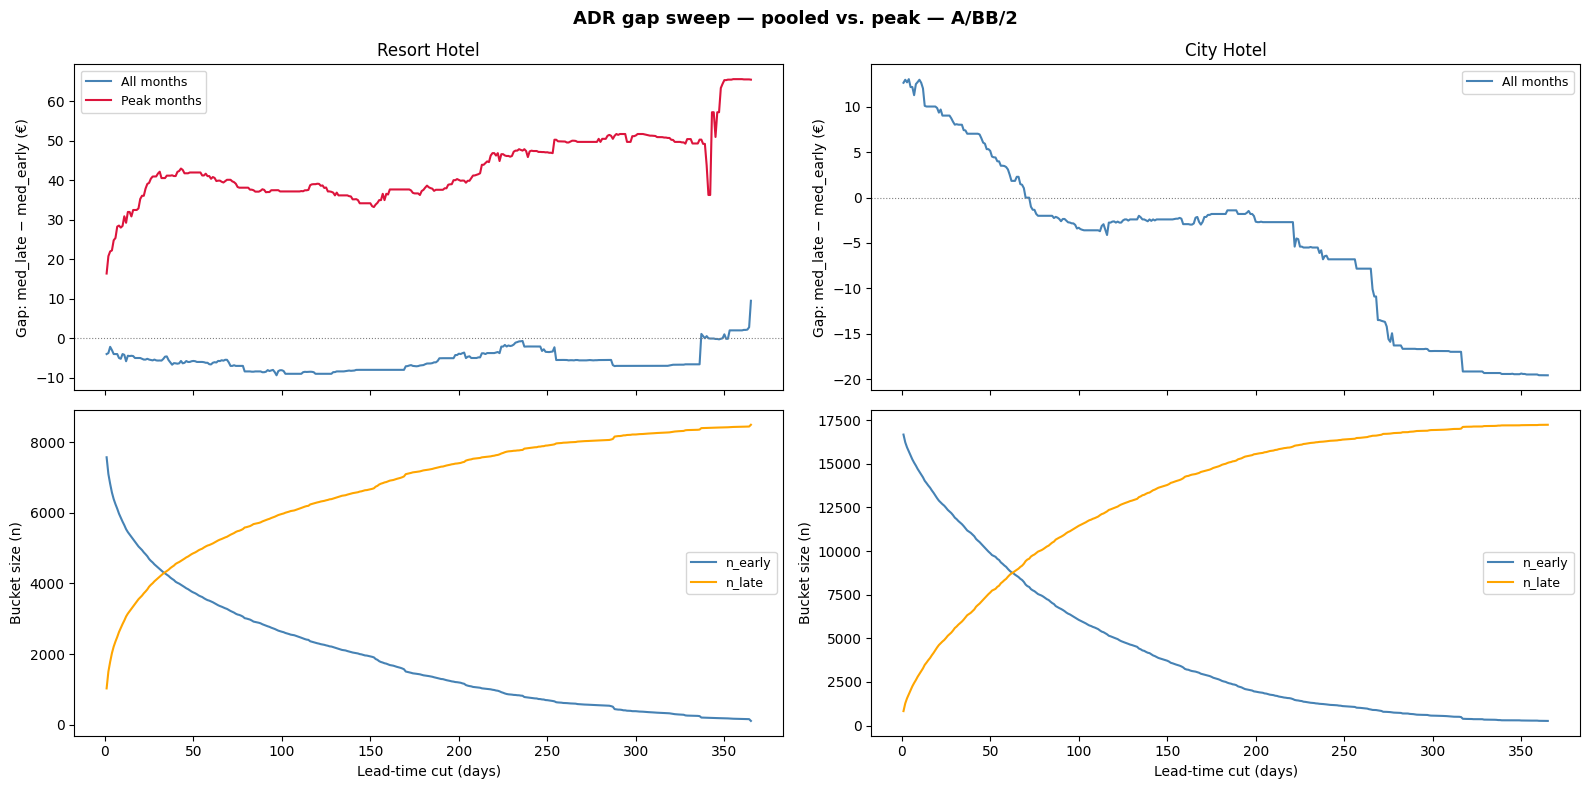

In [11]:
peak_months = {"Resort Hotel": [6, 7, 8]}   # City nutzt das ganze jahr, also keine peak-einschränkung

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex="col")
fig.suptitle(f"ADR gap sweep — pooled vs. peak — {rooms}/{meals}/{adults}",
             fontsize=13, fontweight="bold")

sweeps = {}

for col, hotel in enumerate(hotels):
    # pooled = alle monate: citys finale analyse, resorts baseline
    pooled = gap_sweep(canon_subset(hotel))
    sweeps[(hotel, "pooled")] = pooled

    axes[0, col].plot(pooled["cut"], pooled["gap"],
                      color="steelblue", linewidth=1.5, label="All months")
    axes[1, col].plot(pooled["cut"], pooled["n_early"], color="steelblue", label="n_early")
    axes[1, col].plot(pooled["cut"], pooled["n_late"],  color="orange",    label="n_late")

    # peak nur dort overlayen wo eine high season definiert ist (resort)
    if hotel in peak_months:
        peak = gap_sweep(canon_subset(hotel, peak_months[hotel]))
        sweeps[(hotel, "peak")] = peak
        axes[0, col].plot(peak["cut"], peak["gap"],
                          color="crimson", linewidth=1.5, label="Peak months")

    axes[0, col].axhline(0, color="grey", linestyle=":", linewidth=0.8)
    axes[0, col].set_title(hotel)
    axes[0, col].set_ylabel("Gap: med_late − med_early (€)")
    axes[0, col].legend(fontsize=9)

    axes[1, col].set_xlabel("Lead-time cut (days)")
    axes[1, col].set_ylabel("Bucket size (n)")
    axes[1, col].legend(fontsize=9)

plt.tight_layout()
plt.show()

The contrast between the two Resort curves show key results. Across all months, the gap sits near zero and is in fact slightly negative over most cuts, which on its own would suggest that early bookers pay no more than late ones. Restricting to the summer high season reverses this completely: the gap is positive across the entire range. Pooling does not merely dilute the timing effect, it masks and inverts it. Only within the high season, where the hotel holds genuine pricing power, does the true lead-time effect emerge. The seasonal restriction is therefore not optional for Resort.

City Hotel behaves differently. Its full-year gap is positive only at short cuts and turns negative beyond that. Late guests pay a premium only at short booking horizons, consistent with last-minute corporate demand, so any advance-sale boundary for City has to sit within that early window. The bucket-size panels confirm that both sides of the cut stay well populated across the relevant range for both hotels.

#### Heterogeneity Analysis Across Temporal Subperiods

The peak gap could in principle be produced by a single dominant slice of the season rather than by booking timing itself. We therefore re-run the sweep on subsets and overlay them on the combined curve. For Resort Hotel we split by individual peak month, for City Hotel by quarter. If the subset curves track the combined curve in shape and sign, the gap is a genuine lead-time effect rather than an artefact of mixing. A thin-bucket guard of at least 30 observations per side keeps unstable medians from sparse subsets out of the comparison.

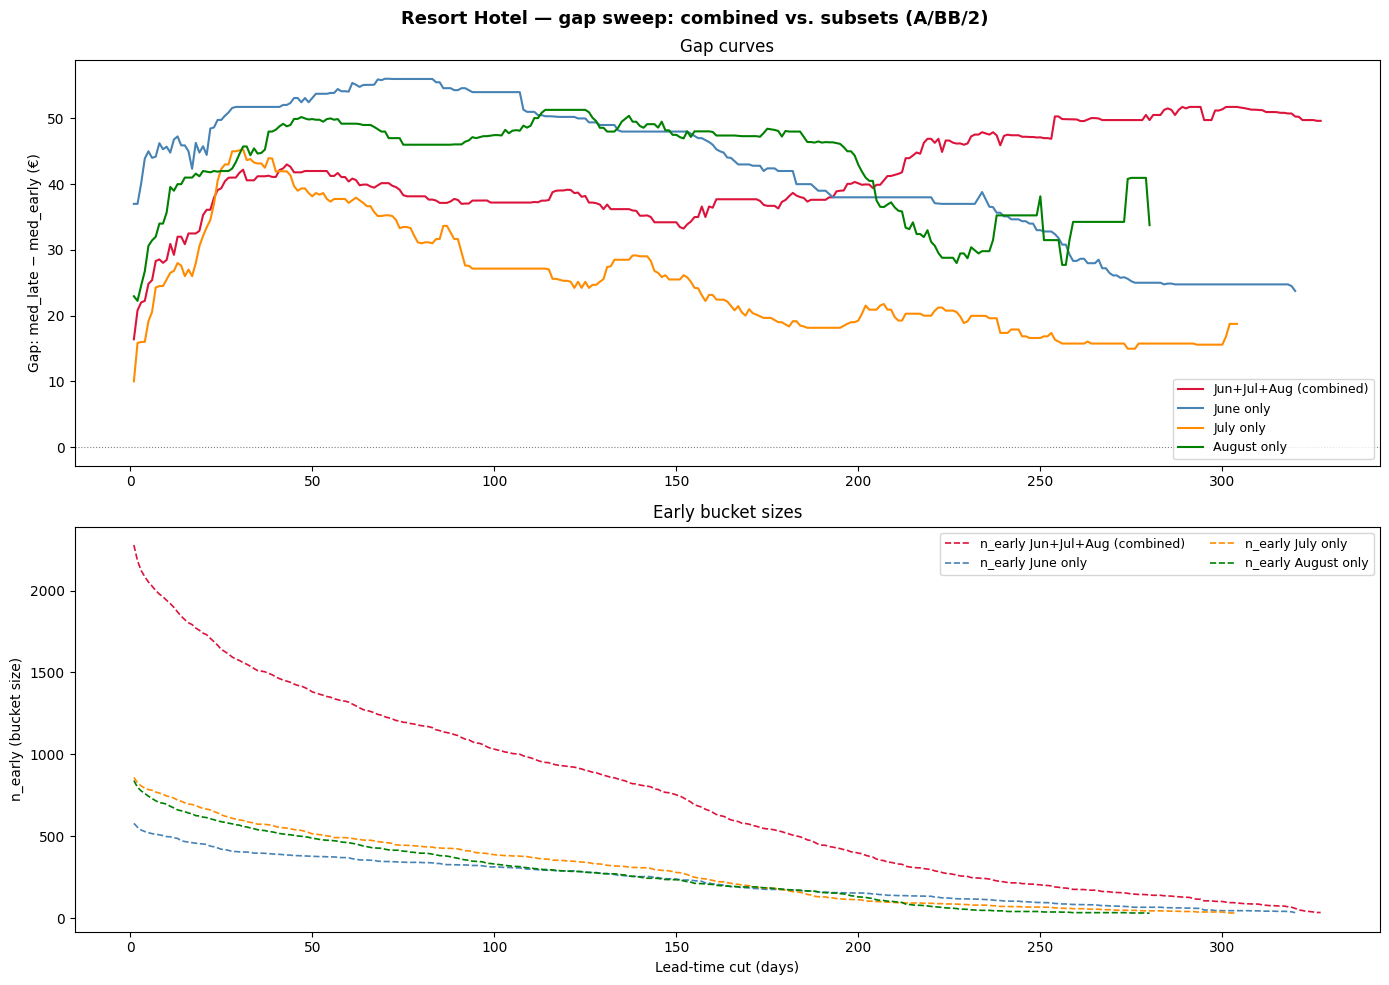

In [12]:
def plot_heterogeneity(hotel, subsets, colors, min_n=30):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f"{hotel} — gap sweep: combined vs. subsets ({rooms}/{meals}/{adults})",
                 fontsize=13, fontweight="bold")

    for label, months in subsets.items():
        s = gap_sweep(canon_subset(hotel, months), min_n=min_n)
        if s.empty:
            continue
        axes[0].plot(s["cut"], s["gap"], color=colors[label], linewidth=1.5, label=label)
        axes[1].plot(s["cut"], s["n_early"], color=colors[label], linewidth=1.2,
                     linestyle="--", label=f"n_early {label}")

    axes[0].axhline(0, color="grey", linestyle=":", linewidth=0.8)
    axes[0].set_ylabel("Gap: med_late − med_early (€)")
    axes[0].set_title("Gap curves")
    axes[0].legend(fontsize=9)

    axes[1].set_xlabel("Lead-time cut (days)")
    axes[1].set_ylabel("n_early (bucket size)")
    axes[1].set_title("Early bucket sizes")
    axes[1].legend(fontsize=9, ncol=2)

    plt.tight_layout()
    plt.show()

plot_heterogeneity(
    "Resort Hotel",
    subsets={
        "Jun+Jul+Aug (combined)": [6, 7, 8],
        "June only": [6], "July only": [7], "August only": [8],
    },
    colors={
        "Jun+Jul+Aug (combined)": "crimson",
        "June only": "steelblue", "July only": "darkorange", "August only": "green",
    },
)

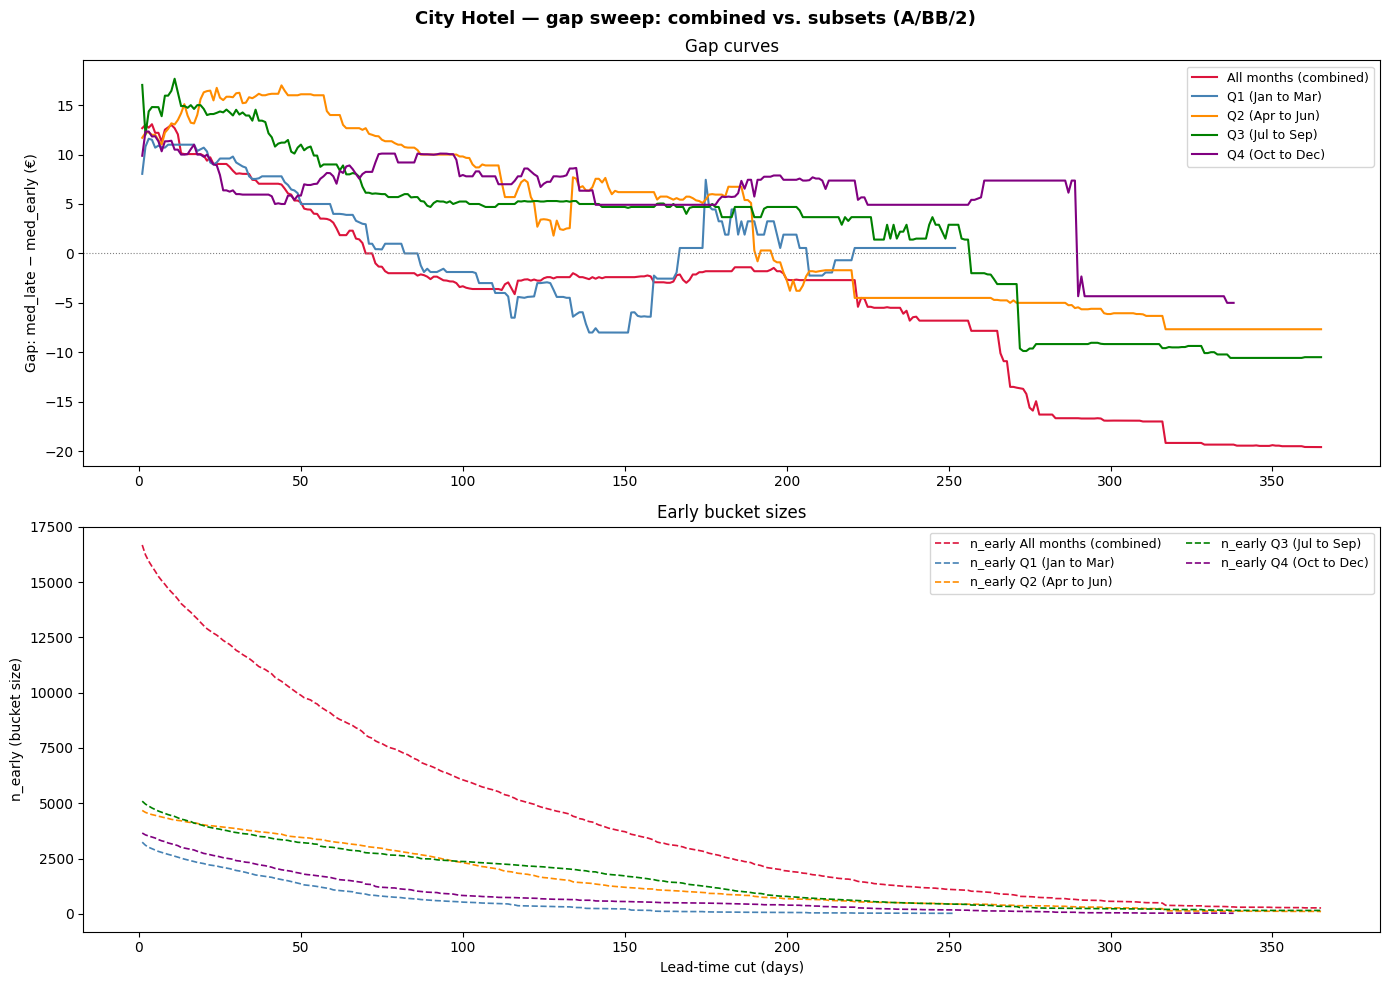

In [13]:
plot_heterogeneity(
    "City Hotel",
    subsets={
        "All months (combined)": None,
        "Q1 (Jan to Mar)": [1, 2, 3], "Q2 (Apr to Jun)": [4, 5, 6],
        "Q3 (Jul to Sep)": [7, 8, 9], "Q4 (Oct to Dec)": [10, 11, 12],
    },
    colors={
        "All months (combined)": "crimson",
        "Q1 (Jan to Mar)": "steelblue", "Q2 (Apr to Jun)": "darkorange",
        "Q3 (Jul to Sep)": "green", "Q4 (Oct to Dec)": "purple",
    },
)

The subset curves confirm that the Resort gap is a genuine lead-time effect. June, July and August each produce a clearly positive gap across the full range, all tracking the combined curve in sign and broad shape. July is the weakest of the three but stays well above zero, and no single month drives the result. We can therefore size the advance-sale cut on the combined peak data with confidence.

For City Hotel the picture is more nuanced. At short lead times, the region where City's pooled gap is positive, all four quarters agree, each showing a premium of roughly €8 to €17. The short-horizon late premium is therefore robust rather than a seasonal artefact. At longer cuts the quarters diverge, and the combined curve falls below every individual quarter, reaching about €-20 where the quarters bottom out around €-5 to €-10. This deep negative tail is an aggregation effect rather than a within-period signal, which reinforces that City's usable advance-sale boundary belongs in the short-horizon window.

### Minimum Volume Thresholds 

A median is only trustworthy if it rests on enough observations. Before selecting a cut, we define the minimum for each bucket to hold at least 5% of the hotel's canonical bookings. The same 5% rule is applied to both hotels, which scales the threshold to each property's size.

In [14]:
min_n = {
    hotel: int(round(0.05 * (canon["hotel"] == hotel).sum()))
    for hotel in hotels
}

display(pd.DataFrame({
    "Hotel": list(min_n),
    "Canonical bookings": [int((canon["hotel"] == h).sum()) for h in min_n],
    "5% min_n": list(min_n.values()),
}))

,Hotel,Canonical bookings,5% min_n
0,Resort Hotel,8600,430
1,City Hotel,17506,875


### Determination of Optimal Lead Time Cut-offs

We evaluate three candidate cuts per hotel, each optimising a different criterion. The plateau center, a stable cut within 95% of the maximum gap; the maximum-gap cut; and the most balanced split, closest to equal bucket sizes. 

Candidates are only sought where the gap is positive, since a cut at which late bookers pay no premium carries no advance-sale meaning. For Resort Hotel this covers essentially the whole peak sweep. For City Hotel it restricts the search to the short-horizon window identified earlier.

In [ ]:
sweep_data = {
    "Resort Hotel": canon_subset("Resort Hotel", peak_months.get("Resort Hotel")),  # peak months
    "City Hotel":   canon_subset("City Hotel",   peak_months.get("City Hotel")),    # None: full year
}

def select_candidates(sweep):
    plateau = sweep[sweep["gap"] >= 0.95 * sweep["gap"].max()]          #helper funktion für unsere Kandidaten
    return {
        "plateau": int(round(plateau["cut"].median())),
        "max_gap": int(sweep.loc[sweep["gap"].idxmax(), "cut"]),
        "balance": int(sweep.loc[(sweep["n_early"] - sweep["n_late"]).abs().idxmin(), "cut"]),
    }

picks = {}
rows = []
for hotel in hotels:
    sweep = gap_sweep(sweep_data[hotel], min_n=min_n[hotel])
    pos = sweep[sweep["gap"] > 0]                 # nur positiver bereich für die suche
    cand = select_candidates(pos)
    picks[hotel] = {"sweep": sweep, **cand}

    for label in ["plateau", "max_gap", "balance"]:
        cut = cand[label]
        r = sweep.loc[(sweep["cut"] - cut).abs().idxmin()]
        rows.append({
            "Hotel": hotel, "Criterion": label, "Cut (d)": cut,
            "Gap (€)": round(r["gap"], 1),
            "med_early": round(r["med_early"], 1),
            "med_late":  round(r["med_late"], 1),
            "n_early": int(r["n_early"]), "n_late": int(r["n_late"]),
        })

display(pd.DataFrame(rows))

,Hotel,Criterion,Cut (d),Gap (€),med_early,med_late,n_early,n_late
0,Resort Hotel,plateau,44,42.6,107.9,150.5,1440,1044
1,Resort Hotel,max_gap,43,43.0,108.0,151.0,1447,1037
2,Resort Hotel,balance,68,39.8,105.2,145.0,1244,1240
3,City Hotel,plateau,8,12.5,91.5,104.0,14895,2611
4,City Hotel,max_gap,4,13.1,91.9,105.0,15706,1800
5,City Hotel,balance,63,1.8,92.6,94.5,8730,8776


For Resort Hotel the three candidates converge closely. The plateau center falls at 44 days and the maximum gap at 43 days, a one-day difference that confirms the choice sits firmly inside the stable region rather than on a spike. The balanced split at 68 days trades a marginal reduction in gap (€39.8 versus €43.0) for near-equal buckets. We select 43 days, the maximum-gap cut, with well-populated buckets on both sides (n_early = 1,447, n_late = 1,037).

For City Hotel the gap-based criteria point to a much shorter cut of 4-8 days, reflecting that City's late premium is confined to the final stretch before arrival. The balanced split, by contrast, lands at 63 days, right at the point where the gap has already decayed to zero. Because a balanced cut here would carry no price premium, we reject it and adopt the plateau cut of 8 days as City's advance-sale boundary.

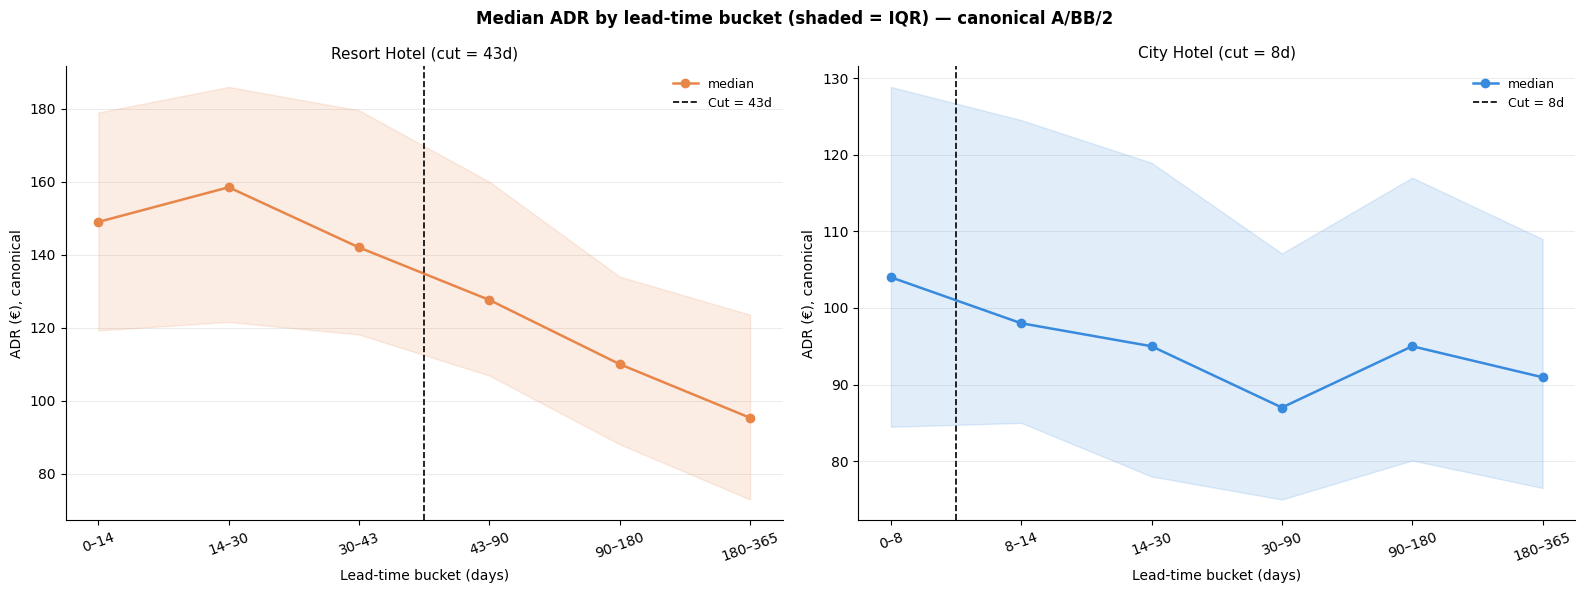

In [16]:
def make_bins(cut, base=(0, 14, 30, 90, 180, 365)): #bin kanten + cut als exakte grenze mit passenden labels
    edges = sorted(set(base) | {cut})
    labels = [f"{lo}–{hi}" for lo, hi in zip(edges[:-1], edges[1:])]
    return edges, labels

def bucket_plot(ax, hotel, cut, color):
    edges, labels = make_bins(cut)
    d = canon_subset(hotel, peak_months.get(hotel)).copy()
    d["lt_bucket"] = pd.cut(d["lead_time"], bins=edges, labels=labels, right=False)

    agg = (
        d.groupby("lt_bucket", observed=True)["adr"]
        .agg(median="median",
             q25=lambda x: x.quantile(.25),
             q75=lambda x: x.quantile(.75),
             n="count")
        .reset_index()
    )

    x = range(len(agg))
    ax.plot(x, agg["median"], color=color, marker="o", markersize=6,
            linewidth=1.8, label="median")
    ax.fill_between(x, agg["q25"], agg["q75"], color=color, alpha=0.15)
    ax.axvline(edges.index(cut) - 0.5, color="black", linestyle="--",
               linewidth=1.2, label=f"Cut = {cut}d")

    ax.set_title(f"{hotel} (cut = {cut}d)", fontsize=11)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20)
    ax.set_xlabel("Lead-time bucket (days)")
    ax.set_ylabel("ADR (€), canonical")
    ax.legend(fontsize=9, frameon=False)
    ax.yaxis.grid(True, linewidth=0.4, color="gainsboro")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

# welcher cut pro hotel in den plot soll 
chosen_cut = {
    "Resort Hotel": picks["Resort Hotel"]["max_gap"],
    "City Hotel":   picks["City Hotel"]["plateau"],
}
hotel_colors = {"City Hotel": "#378ADD", "Resort Hotel": "#E8864A"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Median ADR by lead-time bucket (shaded = IQR) — canonical A/BB/2",
             fontsize=12, fontweight="bold")

for ax, hotel in zip(axes, hotels):
    bucket_plot(ax, hotel, chosen_cut[hotel], hotel_colors[hotel])

plt.tight_layout()
plt.show()

The lead-time bucket plot shows how strongly each hotel can price by booking timing.

For Resort Hotel the effect is strong and clean. Every bucket below the 43-day cut stays near rack level, between €142 and €159, with the peak in the 14 to 30 day window. A guest booking within six weeks of arrival pays close to the top rate regardless of exactly when they book. Past the cut the price falls steadily with lead time andd the IQR bands tighten alongside, so the deepest discounts are also the most consistent. The cut therefore separates a uniformly high-fare late segment from a progressively discounted early one, which is exactly the structure advance-sale pricing relies on.

For City Hotel the same mechanism is barely present. The cut sits at just 8 days and the step there is small, from about €105 in the final days to €99 just beyond. Further out the curve does not decline cleanly at all. It dips to a trough near €87 around 30 to 90 days and then climbs back to roughly €95, so the lowest fares fall in the middle of the booking horizon rather than at the longest lead times. There is no monotonic early discount to capture. City can charge a slight last-minute premium, but booking timing is not a lever it can use to reward early commitment.

### Segment Characterization

So far we have established a timing split. Within Resort's high season, a 43-day cut separates a consistently high-fare late segment from a progressively discounted early one, a roughly €43 gap that survives the per-month heterogeneity check.

A price gap between two lead-time buckets is only a usable lever if those buckets map onto recognisable, addressable guest segments. A price rate Clara cannot target is lost possible revenue. We need to know who sits on each side and through which channel they arrive, so that "cap the advance bucket" becomes a concrete action, such as repricing or limiting a specific channel or contract. We therefore describe each side of the cut by its customer-type and distribution-channel mix. This serves two purposes. 

First, it corroborates the timing story on an independent axis. If the early bucket is a genuinely different kind of demand, the segmentation has real structure rather than a bare statistical gap. 
Second, it identifies the levers that actually move the advance bucket. We keep the same population the cut was measured on, so the description matches the gap it explains.

We run Resort first. Because City's lead-time lever turned out to be weak, its segment split is examined mainly to confirm that no strong, distinct advance segment exists there, and the per-hotel comparison follows.

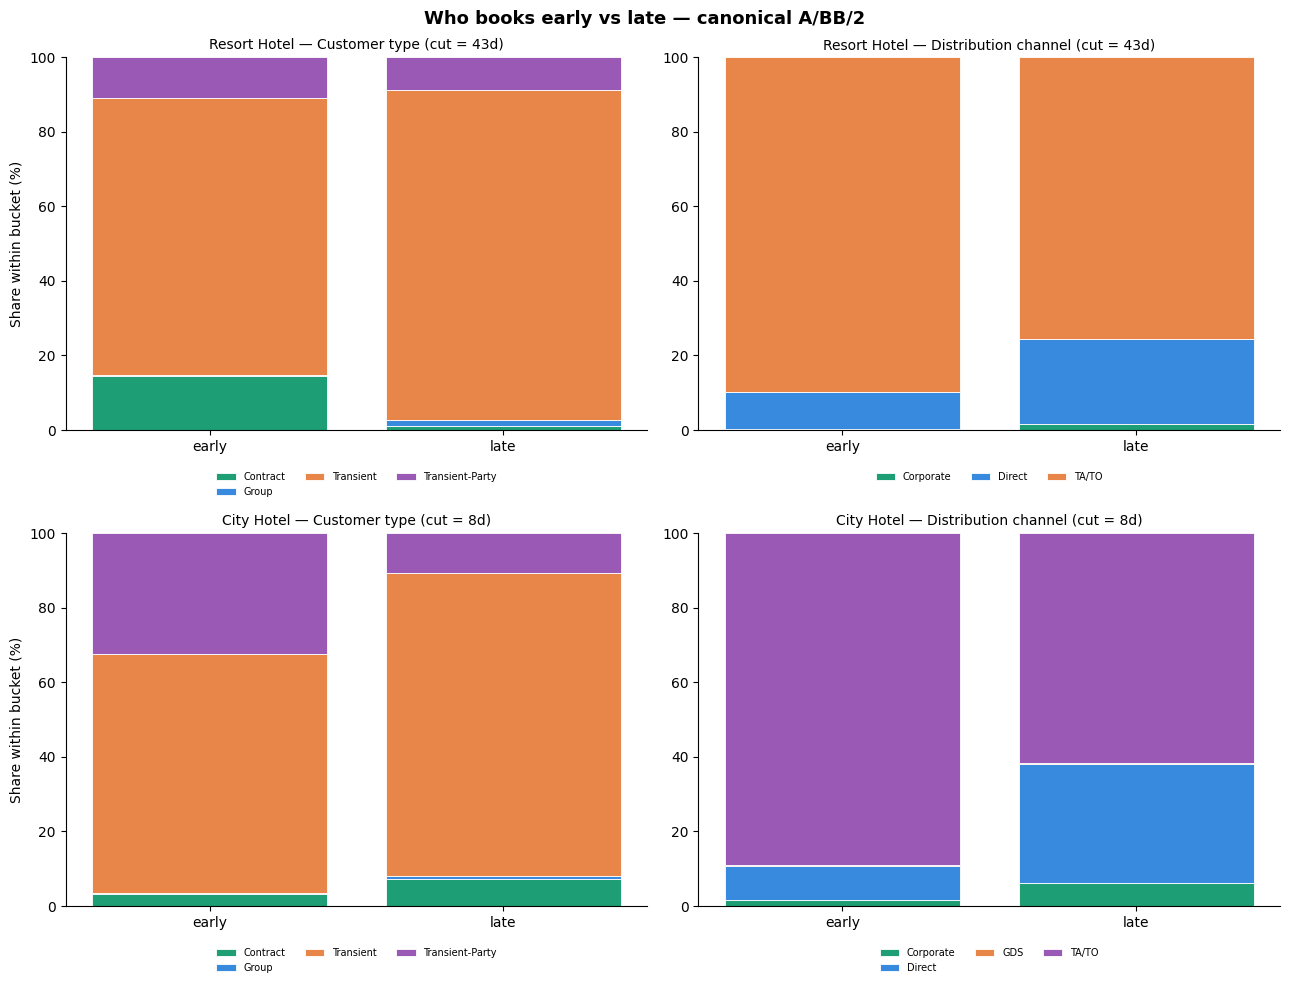

Bucket sizes (n)


,Resort Hotel,City Hotel
side,,
early,1447,14895
late,1037,2611


Customer type — % within side


customer_type       Contract  Group  Transient  Transient-Party
hotel        side                                              
Resort Hotel early      14.6    0.1       74.5             10.9
             late        1.1    1.5       88.6              8.8
City Hotel   early       3.2    0.3       64.2             32.3
             late        7.2    0.7       81.3             10.8

Distribution channel — % within side


distribution_channel  Corporate  Direct  TA/TO  GDS
hotel        side                                  
Resort Hotel early          0.3     9.7   89.9  0.0
             late           1.5    22.9   75.6  0.0
City Hotel   early          1.6     9.2   89.1  0.0
             late           6.3    31.9   61.7  0.1

In [17]:
palette = ["#1D9E75", "#378ADD", "#E8864A", "#9B59B6", "#E24B4A", "#7F8C8D"]

seg_cut = {"Resort Hotel": 43, "City Hotel": 8}   

# segmentierte daten pro hotel einmal bauen
seg = {}
for h in hotels:
    d = canon_subset(h, peak_months.get(h)).copy()
    d["side"] = np.where(d["lead_time"] >= seg_cut[h], "early", "late")
    seg[h] = d

#2x2 grid: zeilen = hotels, spalten = customer_type / channel
dims = [("customer_type", "Customer type"), ("distribution_channel", "Distribution channel")]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Who books early vs late — canonical A/BB/2", fontsize=13, fontweight="bold")

for r, hotel in enumerate(hotels):
    for c, (col, title) in enumerate(dims):
        ax = axes[r, c]
        mix = (seg[hotel].groupby("side")[col].value_counts(normalize=True)
                 .unstack().fillna(0) * 100).reindex(["early", "late"])
        bottom = np.zeros(len(mix))
        for i, cat in enumerate(mix.columns):
            ax.bar(mix.index, mix[cat], bottom=bottom, label=cat,
                   color=palette[i % len(palette)], edgecolor="white", linewidth=0.6)
            bottom += mix[cat].to_numpy()
        ax.set_title(f"{hotel} — {title} (cut = {seg_cut[hotel]}d)", fontsize=10)
        ax.set_ylim(0, 100)
        if c == 0:
            ax.set_ylabel("Share within bucket (%)")
        ax.legend(frameon=False, fontsize=7, loc="upper center",
                  bbox_to_anchor=(0.5, -0.09), ncol=3)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# tabellen: beide hotels nebeneinander
def mix_table(col):
    parts = []
    for h in hotels:
        m = (seg[h].groupby("side")[col].value_counts(normalize=True)
               .unstack().fillna(0) * 100).reindex(["early", "late"]).round(1)
        m.index = pd.MultiIndex.from_product([[h], m.index], names=["hotel", "side"])
        parts.append(m)
    return pd.concat(parts).fillna(0)

bucket_sizes = pd.DataFrame({h: seg[h]["side"].value_counts() for h in hotels}).reindex(["early", "late"])

print("Bucket sizes (n)")
display(bucket_sizes)

print("Customer type — % within side")
display(mix_table("customer_type"))

print("Distribution channel — % within side")
display(mix_table("distribution_channel"))

The lead-time split does more than separate two price levels. It separates two recognisable kinds of demand, which is what makes the gap addressable.

In the Resort Hotel, both sides are majority Transient, as expected for a leisure resort, so the segmentation shows up in the minority mix rather than a change of dominant type. On the customer axis, Contract demand jumps from 1.1% of late bookers to 14.6% of early ones, so the little contracted or block demand that exists concentrates in the advance window. On the channel axis, early bookings run overwhelmingly through TA/TO (89.9% versus 75.6% late), while late bookings skew Direct (22.9% versus 9.7%). The late bucket is therefore close to pure Transient or Direct booking inside 43 days at the 151 median, while the early bucket is a transient base carrying a distinct Contract and TA/TO tail booking 43 or more days out at a 108 median. The advance discount is partly targetable. The slice Clara most directly controls is the contracted and TA/TO volume she releases early.

In the City Hotel, the composition shifts clearly too, but in a different direction. The last-minute bucket under 8 days is far more Direct (31.9% versus 9.2%) and Corporate (6.3% versus 1.6%), while the advance bucket runs heavily through TA/TO (89.1%) and carries more Transient-Party bookings (32.3% versus 10.8%). City's advance window is leisure parties booking ahead through agents, and its last-minute window is lone Direct and Corporate guests. The segment is identifiable. What it does not carry is a price premium, since City's late ADR sits barely above its early median (91.5 vs 104). The last-minute business segment is real but cannot be monetised through lead-time pricing.

The two hotels call for opposite instincts. At Resort, late bookers pay a large premium, so rooms are worth protecting from the advance discount. At City, the identifiable last-minute segment pays little more than early bookers, so there is little revenue to protect and the advance allocation can stay generous. 

### Analysis of Temporal Booking Patterns

The cut tells us where to split early from late and who sits on each side. To turn that into an advance-sale limit we need one more quantity. How much advance demand actually exists. We read this from the reverse-cumulative booking curve, the share of the final realised bookings already on hand at each lead time. Its value at the cut, F_early, is the share of demand booking at lead time at or above the cut, and it bounds how large the advance pool can be.

F_early is computed on all realised bookings, not just the canonical tuple, because the advance limit is allocated over the whole inventory and a volume share does not need the homogenisation the price signal required. The canonical value is reported alongside as a robustness check.

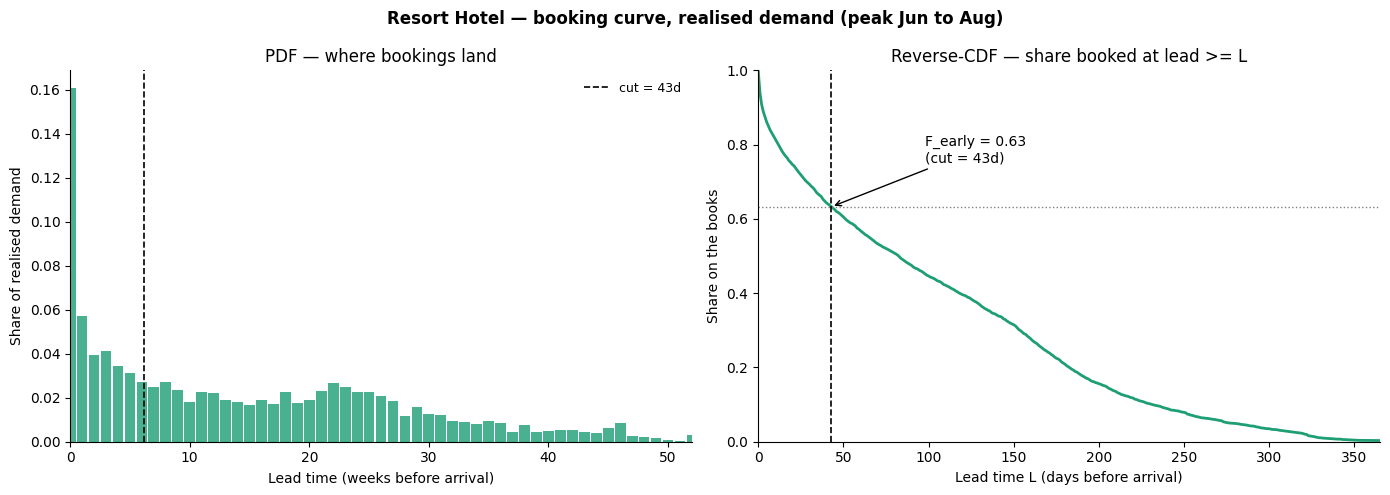

Resort Hotel: F_early(>= 43d) all=0.633 | canonical=0.583 | median lead 82d, n=8432


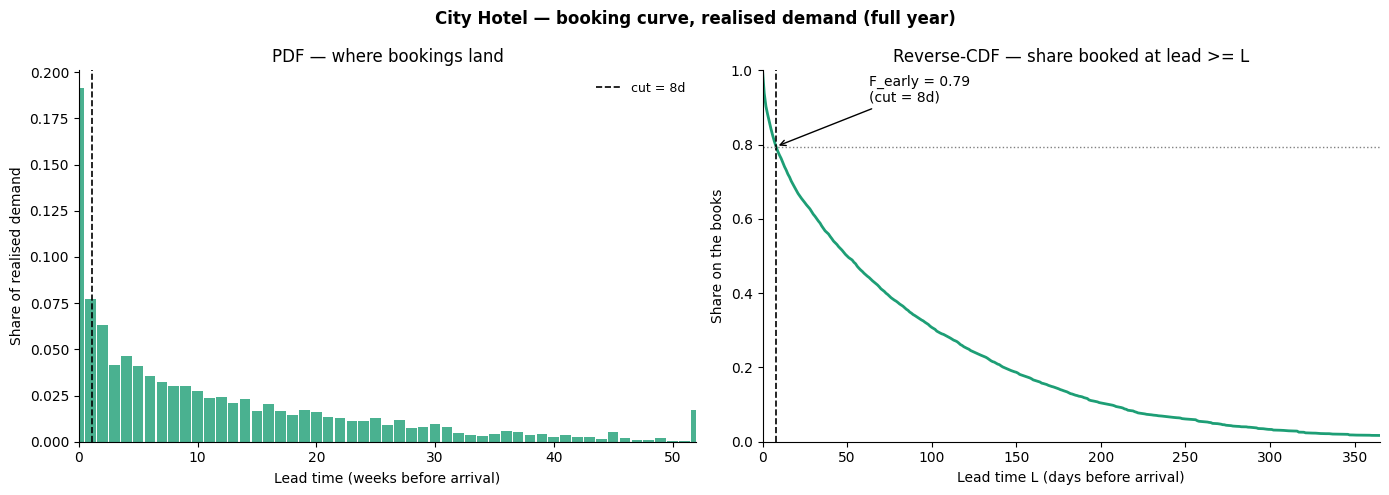

City Hotel: F_early(>= 8d) all=0.795 | canonical=0.851 | median lead 50d, n=46228


np.float64(0.7947347927662888)

In [ ]:
def hotel_subset(hotel, months=None):
    df = realised[realised["hotel"] == hotel]       #helper: holt alle realisierten bookings eines hotels
    if months is not None:
        df = df[df["arrival_date"].dt.month.isin(months)]
    return df

cand_df = pd.DataFrame(rows)

def fares_at_cut(hotel, cut):                               #helper: holt med_early (p_L) und med_late (p_H) am cut, aus der kandidaten-tabelle.
    r = cand_df[(cand_df["Hotel"] == hotel) & (cand_df["Cut (d)"] == cut)].iloc[0]
    return r["med_early"], r["med_late"]

def booking_curve(hotel, cut, color="#1D9E75"):
    pop   = hotel_subset(hotel, peak_months.get(hotel))   # alle zimmer (volumen über ganzes inventar)
    pop_c = canon_subset(hotel, peak_months.get(hotel))   # kanonisch, nur als robustness

    F_early   = (pop["lead_time"]   >= cut).mean()
    F_early_c = (pop_c["lead_time"] >= cut).mean()

    months_lbl = "peak Jun to Aug" if peak_months.get(hotel) else "full year"
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{hotel} — booking curve, realised demand ({months_lbl})",
                 fontsize=12, fontweight="bold")

    weeks = (pop["lead_time"].clip(upper=365) // 7)
    w_share = weeks.value_counts(normalize=True).sort_index()
    ax = axes[0]
    ax.bar(w_share.index, w_share.values, color=color, alpha=0.8, width=0.9)
    ax.axvline(cut / 7, color="black", linestyle="--", linewidth=1.2, label=f"cut = {cut}d")
    ax.set_title("PDF — where bookings land")
    ax.set_xlabel("Lead time (weeks before arrival)")
    ax.set_ylabel("Share of realised demand")
    ax.set_xlim(0, 52)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    grid = np.arange(0, 366)
    surv = [(pop["lead_time"] >= L).mean() for L in grid]
    ax.plot(grid, surv, color=color, linewidth=2)
    ax.axvline(cut, color="black", linestyle="--", linewidth=1.2)
    ax.axhline(F_early, color="grey", linestyle=":", linewidth=1)
    ax.annotate(f"F_early = {F_early:.2f}\n(cut = {cut}d)",
                xy=(cut, F_early), xytext=(cut + 55, min(F_early + 0.12, 0.95)),
                arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)
    ax.set_title("Reverse-CDF — share booked at lead >= L")
    ax.set_xlabel("Lead time L (days before arrival)")
    ax.set_ylabel("Share on the books")
    ax.set_xlim(0, 365); ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f"{hotel}: F_early(>= {cut}d) all={F_early:.3f} | canonical={F_early_c:.3f} | "
          f"median lead {pop['lead_time'].median():.0f}d, n={len(pop)}")
    return F_early

booking_curve("Resort Hotel", 43)
booking_curve("City Hotel", 8)

The booking curve says how much advance demand exists, not how much we should sell in advance. That depends on the price gap and on how uncertain late demand is. With two fare classes, where the low fare (early) books first and the high fare (late) books close to arrival, Littlewood's rule gives the optimal protection level y*, the number of rooms to reserve for late high-fare demand:

$$
P(D_H > y^*) = \frac{p_L}{p_H} \qquad \text{and} \qquad y^* = F^{-1}\left(1 - \frac{p_L}{p_H}\right)
$$


where $D_H$ is late demand, $p_L$ and $p_H$ are the early and late fares, and $F_H$ is the CDF of late demand. 

The idea is, to accept an early low-fare booking only while the room is worth less than it would be saved for a late high-fare guest. We protect the last room whose chance of being claimed by a late booker, weighted by the fare ratio, still beats selling it early. 

We estimate $D_H$ from realised late bookings per night of all room types and the fares are the canonical medians at the cut.

Resort Hotel:
p_L=108.0, p_H=151.0, ratio=0.715
protect 9 rooms/night (late median 12, nights=246)
P(late >= 9) = 0.760 >= ratio  |  P(late >= 10) = 0.654 < ratio


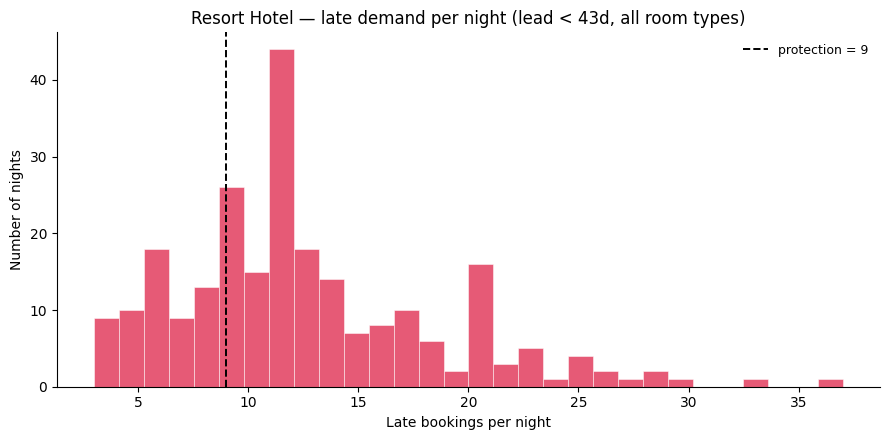

City Hotel:
p_L=91.5, p_H=104.0, ratio=0.880
protect 5 rooms/night (late median 11, nights=772)
P(late >= 5) = 0.892 >= ratio  |  P(late >= 6) = 0.843 < ratio


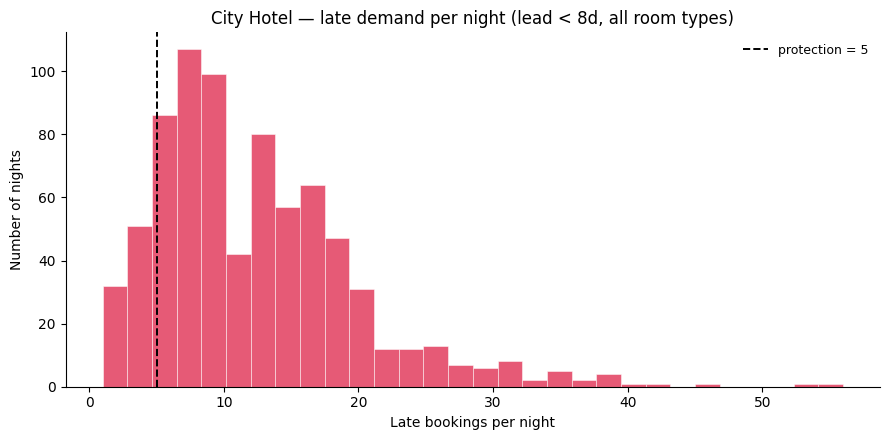

(5, np.float64(0.8796153846153847))

In [24]:
def littlewood(hotel, cut, plot=True):
    pop = hotel_subset(hotel, peak_months.get(hotel))
    p_L, p_H = fares_at_cut(hotel, cut)
    ratio = p_L / p_H

    late_per_night = pop[pop["lead_time"] < cut].groupby("arrival_date").size()

    y_star = 0
    for x in range(1, int(late_per_night.max()) + 1):
        if (late_per_night >= x).mean() >= ratio:
            y_star = x
        else:
            break

    # wahrscheinlichkeiten am protection level: das geschützte und das erste verworfene zimmer
    p_at   = (late_per_night >= y_star).mean()
    p_next = (late_per_night >= y_star + 1).mean()

    print(f"{hotel}:")
    print(f"p_L={p_L:.1f}, p_H={p_H:.1f}, ratio={ratio:.3f}")
    print(f"protect {y_star} rooms/night "
          f"(late median {late_per_night.median():.0f}, nights={len(late_per_night)})")
    print(f"P(late >= {y_star}) = {p_at:.3f} >= ratio  |  "
          f"P(late >= {y_star + 1}) = {p_next:.3f} < ratio")

    if plot:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.hist(late_per_night, bins=30, color="crimson", alpha=0.7,
                edgecolor="white", linewidth=0.5)
        ax.axvline(y_star, color="black", linestyle="--", linewidth=1.4,
                   label=f"protection = {y_star}")
        ax.set_title(f"{hotel} — late demand per night (lead < {cut}d, all room types)")
        ax.set_xlabel("Late bookings per night")
        ax.set_ylabel("Number of nights")
        ax.legend(frameon=False, fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout(); plt.show()

    return y_star, ratio

littlewood("Resort Hotel", 43)
littlewood("City Hotel", 8)

For Resort the fare ratio is     $p_L/p_H$ = 108/151 = 0.715. A room is worth protecting as long as a late booker is at least 71.5% likely to claim it. That holds up to 9 rooms: P(late ≥ 9) = 0.76 clears the bar, the 10th room (P = 0.654) does not. Clara should reserve about 9 rooms per peak night for late high-fare demand and release the rest for advance sale. With a median of 12 late bookings per night, this protection sits comfortably inside typical late demand.

For City the fare ratio is much higher,  $p_L/p_H$ = 0.88, because the late premium is small. A higher bar means a room is only worth protecting when late demand fills it with near certainty, so the optimal protection collapses to 5 rooms. This is expected from the weak-lever finding. With almost no premium to defend, City should sell advance generously and protect very little.

### Limitations for Q1

Two assumptions qualify the protection levels above.

First, late demand is measured from realised bookings only. On any night that sold out, further late requests were turned away and never entered the data, so the observed late demand is capped by capacity rather than reflecting true demand. The protection levels are therefore conservative lower bounds. The real optimum may sit slightly higher.

Second, the fare ratio and the demand volume are drawn from different populations, by design. 

$pL​/pH$​ comes from the canonical tuple A/BB/2, where room type, meal plan, and party size are held constant, so the price signal is clean and not distorted by a shifting room mix. The late-demand distribution, by contrast, is counted over all room types, because the protection level is a number of real rooms allocated across the whole inventory. This combination assumes the canonical price ratio is representative of the property as a whole. If other room types carried a markedly different early-to-late ratio, the recommended level would shift accordingly.